# C6H5ClO PIE 同位素与处理流程诊断

基于原始 PIE 高分辨质谱、项目标定、活动手动峰表和已生成 PIE 缓存。

## tl;dr

- **当前 142/144/146 图使用相同的原始谱、IO 和纵轴单位，但旧积分窗已经失配。** 10/10 个目标峰均不在旧窗口内；TOF 偏移为 38–50 bin（中位数 46）。
- **已知氯同位素对未恢复 3.1:1。** 11 eV 重定位后，127/129=0.018、99/101=0.602、128/130=4.684。
- **144/146 不能视为纯同位素对。** 11 eV 时 I146/I144=0.262，9–11 eV 中位数为 0.242，且随能量显著变化。
- **148 不支持“146 为新的单氯母体”的充分证据。** 11 eV 时 I148/I146=0.174，9–11 eV 中位数仅 0.159，明显低于 0.32。
- **两段扫描不能直接拼接。** 低能段为 90 s/点，高能段为 60 s/点；在 8.00–8.10 eV 重叠区，低能段/高能段在仅除 IO 后的中位数仍只有 0.369，说明还存在额外段间增益/源强差。

## Context & Methods

### Key Assumptions

- 氯天然丰度诊断采用 \(^{35}\mathrm{Cl}/^{37}\mathrm{Cl}\approx3.1\)，等价于 \(I_{M+2}/I_M\approx0.32\)。
- 同一原始谱内的质量比不受 IO 或采集时间的共同乘法因子影响。
- 目标峰位按项目当前二次 TOF→m/z 标定计算，并在 ±7 bin 内用 9.5–11 eV 聚合谱定位峰顶；随后用对称 ±10 bin、线性侧带本底进行积分。
- 使用 ±6、±8、±10、±12 bin 做积分窗敏感性检查。

In [1]:
import os
from pathlib import Path
os.environ.setdefault('MPLCONFIGDIR', '/private/tmp/bl03u_mpl')
os.environ.setdefault('XDG_CACHE_HOME', '/private/tmp/bl03u_cache')
from run_analysis import main

summary = main()
OUTPUT_DIR = Path.cwd()
print('analysis complete:', OUTPUT_DIR)

analysis complete: /Users/huangchen/VscodeProject/BL03U_MSTool_clean_repo/BL03U_MassSpectrumTool/analysis_outputs/c6h5clo_isotope_diagnostic


## Data

In [2]:
import pandas as pd

scan_metadata = pd.read_csv('scan_metadata.csv')
alignment = pd.read_csv('window_alignment.csv')
fixed_ratios = pd.read_csv('fixed_energy_ratio_summary.csv')
shape_tests = pd.read_csv('shape_tests.csv')
sensitivity = pd.read_csv('integration_window_sensitivity.csv')

scan_metadata.groupby('segment').agg(
    files=('file', 'size'),
    energy_min=('energy', 'min'),
    energy_max=('energy', 'max'),
    time_s=('time_s', 'first'),
    io_min=('io_nA', 'min'),
    io_max=('io_nA', 'max'),
)

,files,energy_min,energy_max,time_s,io_min,io_max
segment,,,,,,
PIE,61,7.999819,10.999774,60.0,30.637608,67.399146
PIE-2,23,6.999829,8.100027,90.0,80.299656,174.883215


In [3]:
alignment[[
    'channel', 'label_mz', 'old_center_tof', 'calibrated_center_tof',
    'observed_center_tof', 'tof_offset_bins', 'old_window_contains_peak'
]]

,channel,label_mz,old_center_tof,calibrated_center_tof,observed_center_tof,tof_offset_bins,old_window_contains_peak
0,99,99.00,15541,15580.463159,15580,39,False
1,101,101.02,15708,15747.607075,15746,38,False
2,127,127.05,17723,17767.995495,17766,43,False
3,128,128.00,17792,17837.611234,17839,47,False
4,129,129.00,17865,17910.612553,17914,49,False
5,130,130.00,17937,17983.331583,17982,45,False
6,142,142.06,18791,18839.231805,18838,47,False
7,144,144.02,18926,18974.850829,18976,50,False
8,146,146.02,19063,19112.289990,19111,48,False
9,148,148.01,19199,19248.111235,19244,45,False


## Results

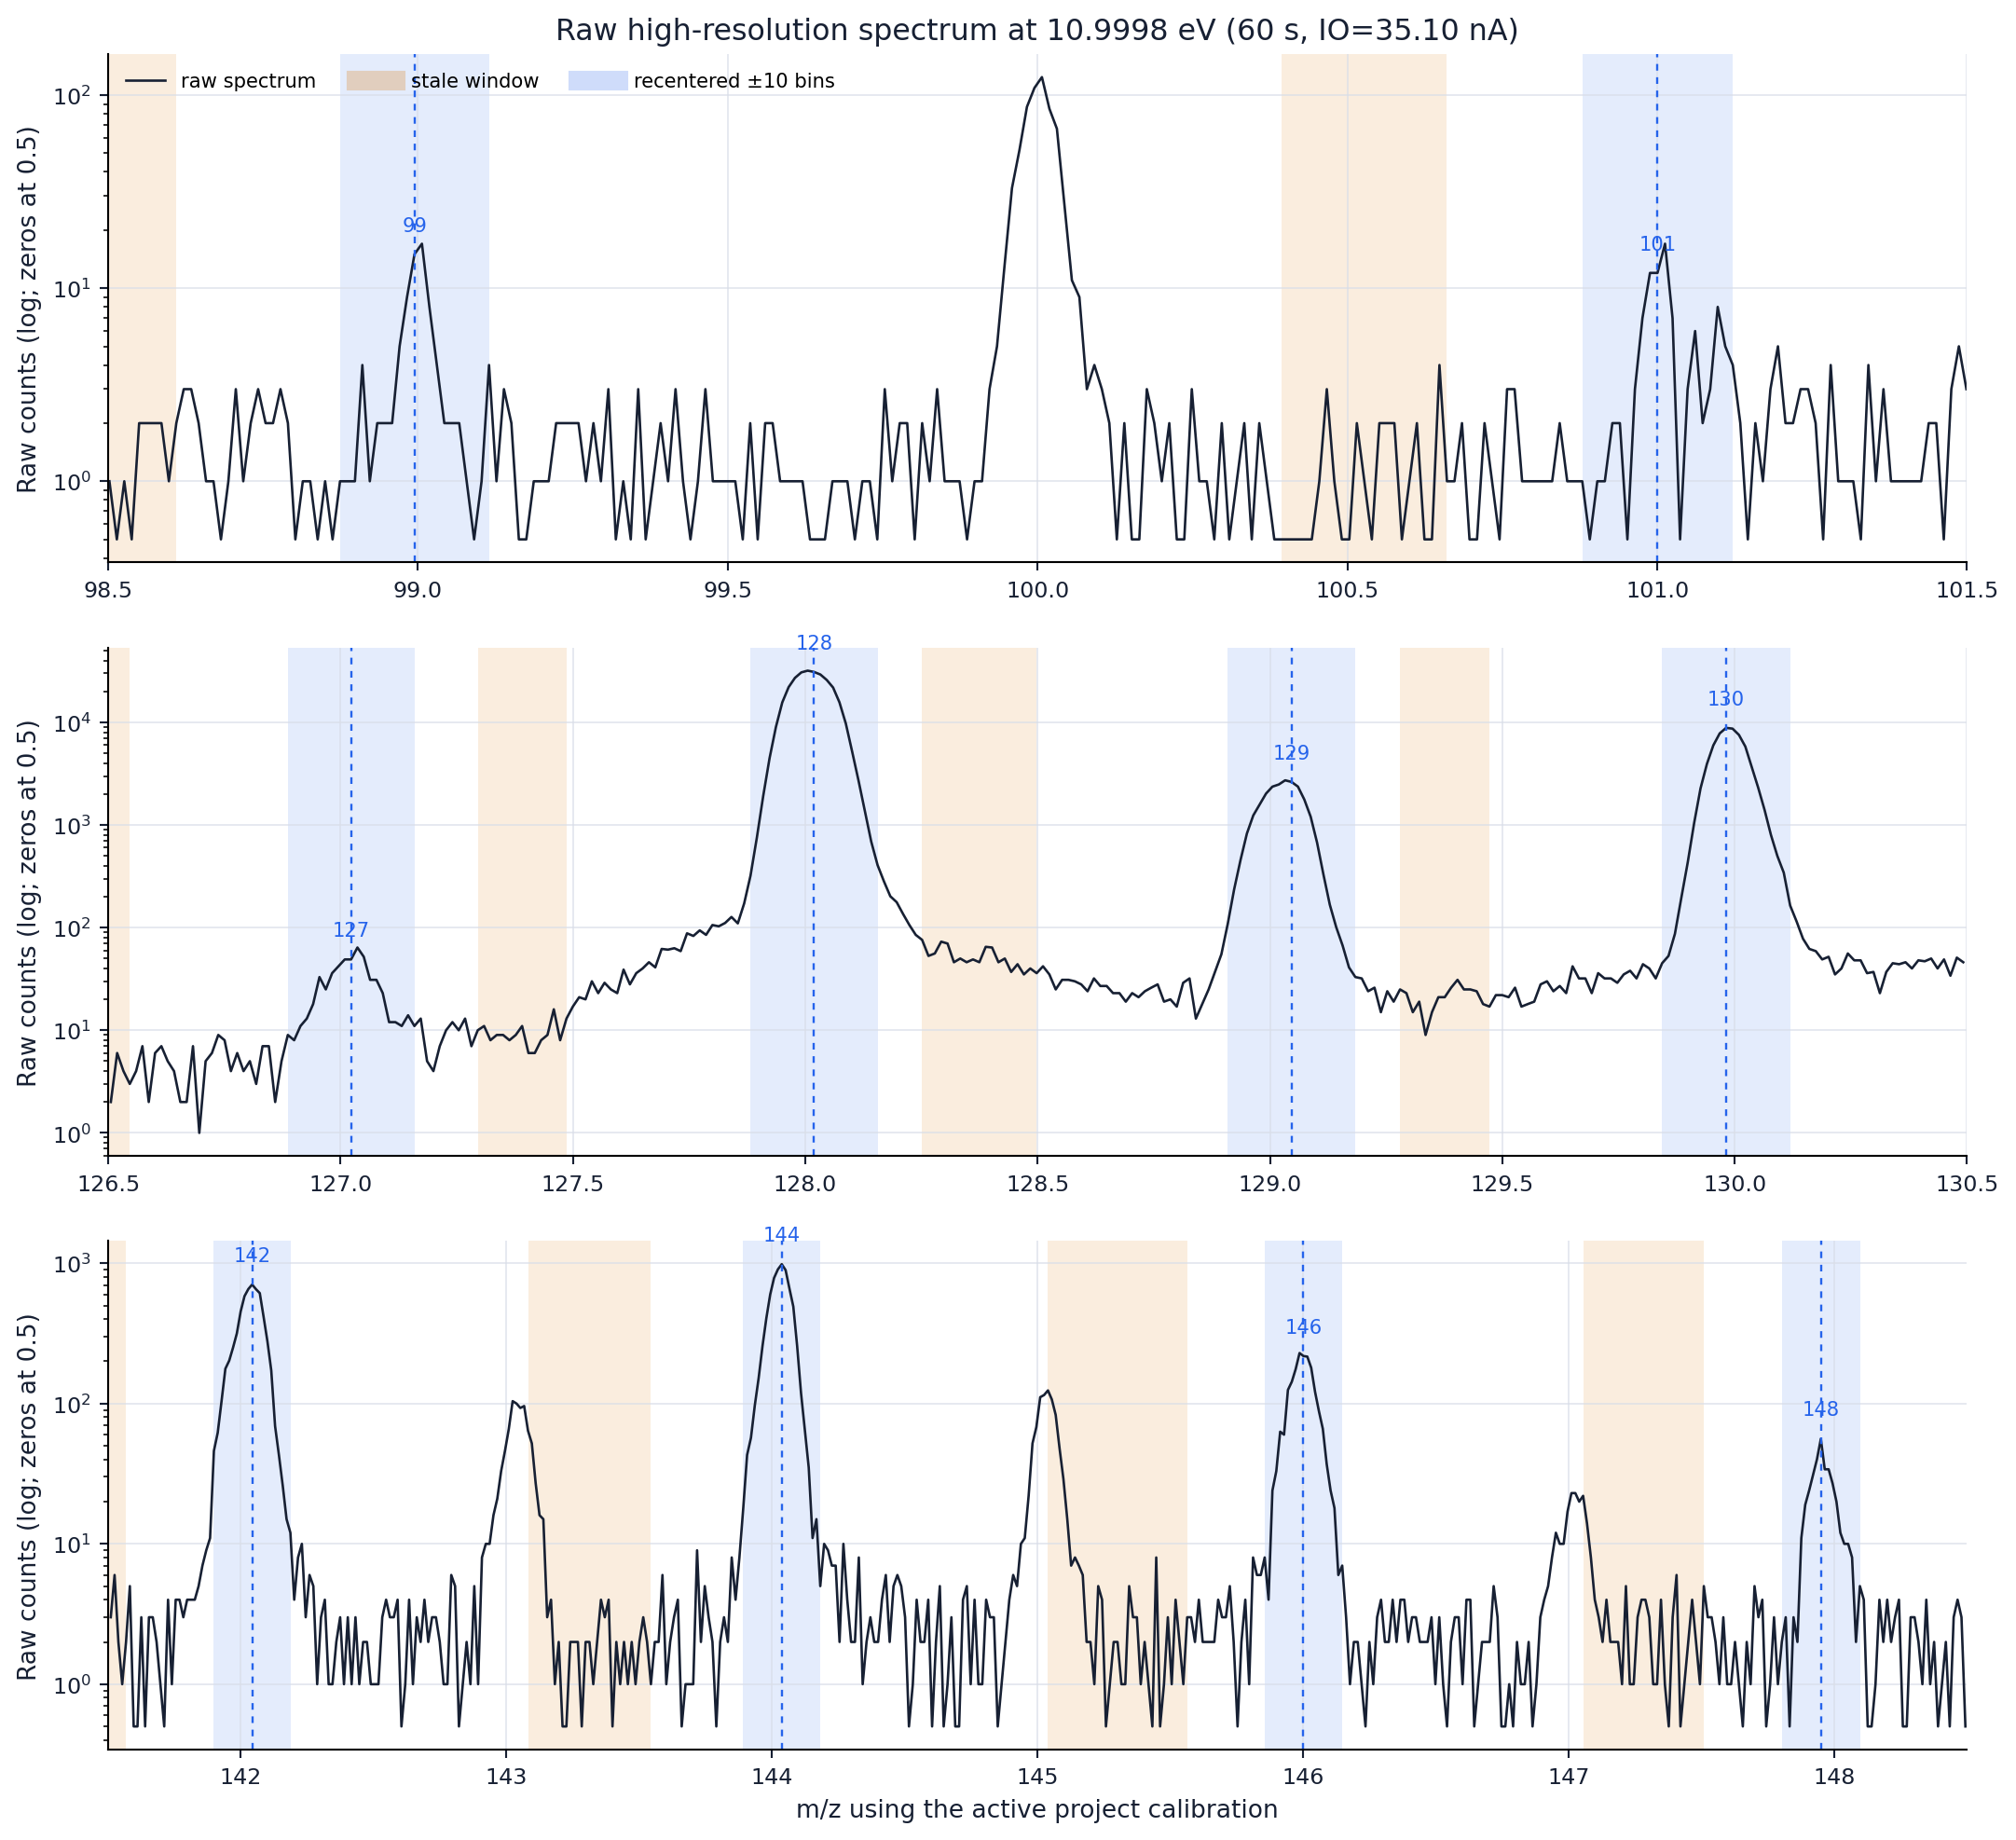

In [4]:
from IPython.display import Image, display

display(Image(filename='fixed_energy_high_resolution_spectrum.png'))

In [5]:
display(fixed_ratios)
display(shape_tests)
display(sensitivity.pivot(index='pair', columns='half_width_bins', values='ratio_at_11eV'))

,pair,purpose,expected_ratio,energy_eV,old_window_ratio,corrected_ratio,corrected_ratio_minus_expected,high_energy_n,high_energy_median,high_energy_q25,high_energy_q75
0,127/129,known chlorine pair,3.10,10.999774,0.063136,0.017958,-3.082042,40,0.016968,0.015842,0.018015
1,99/101,known chlorine pair,3.10,10.999774,0.818182,0.602151,-2.497849,40,0.570620,0.409478,0.835257
2,128/130,known chlorine pair,3.10,10.999774,0.449045,4.683988,1.583988,40,5.581799,5.179886,5.794678
3,146/144,I146/I144 test,0.32,10.999774,2.191111,0.262061,-0.057939,40,0.242240,0.216607,0.263389
4,148/146,I148/I146 test,0.32,10.999774,0.235294,0.174425,-0.145575,40,0.159047,0.136927,0.187112


,pair,expected_ratio,n_energy_points,pearson_r_of_PIE_intensities,pearson_p,best_scale_through_origin,r2_through_origin,ratio_vs_energy_slope_per_eV,ratio_vs_energy_p,ratio_median,ratio_q25,ratio_q75
0,146/144,0.32,40,0.993357,2.683074e-37,0.258356,0.991334,0.067469,5.187066e-13,0.242240,0.216607,0.263389
1,148/146,0.32,40,0.978461,1.201658e-27,0.183032,0.981408,0.047812,1.597433e-08,0.159047,0.136927,0.187112


half_width_bins,6,8,10,12
pair,,,,
127/129,0.017740,0.017558,0.017958,0.017825
128/130,4.627263,4.686975,4.683988,4.684123
146/144,0.257310,0.262933,0.262061,0.261803
148/146,0.174688,0.173446,0.174425,0.174035
99/101,0.792952,0.664093,0.602151,0.567273


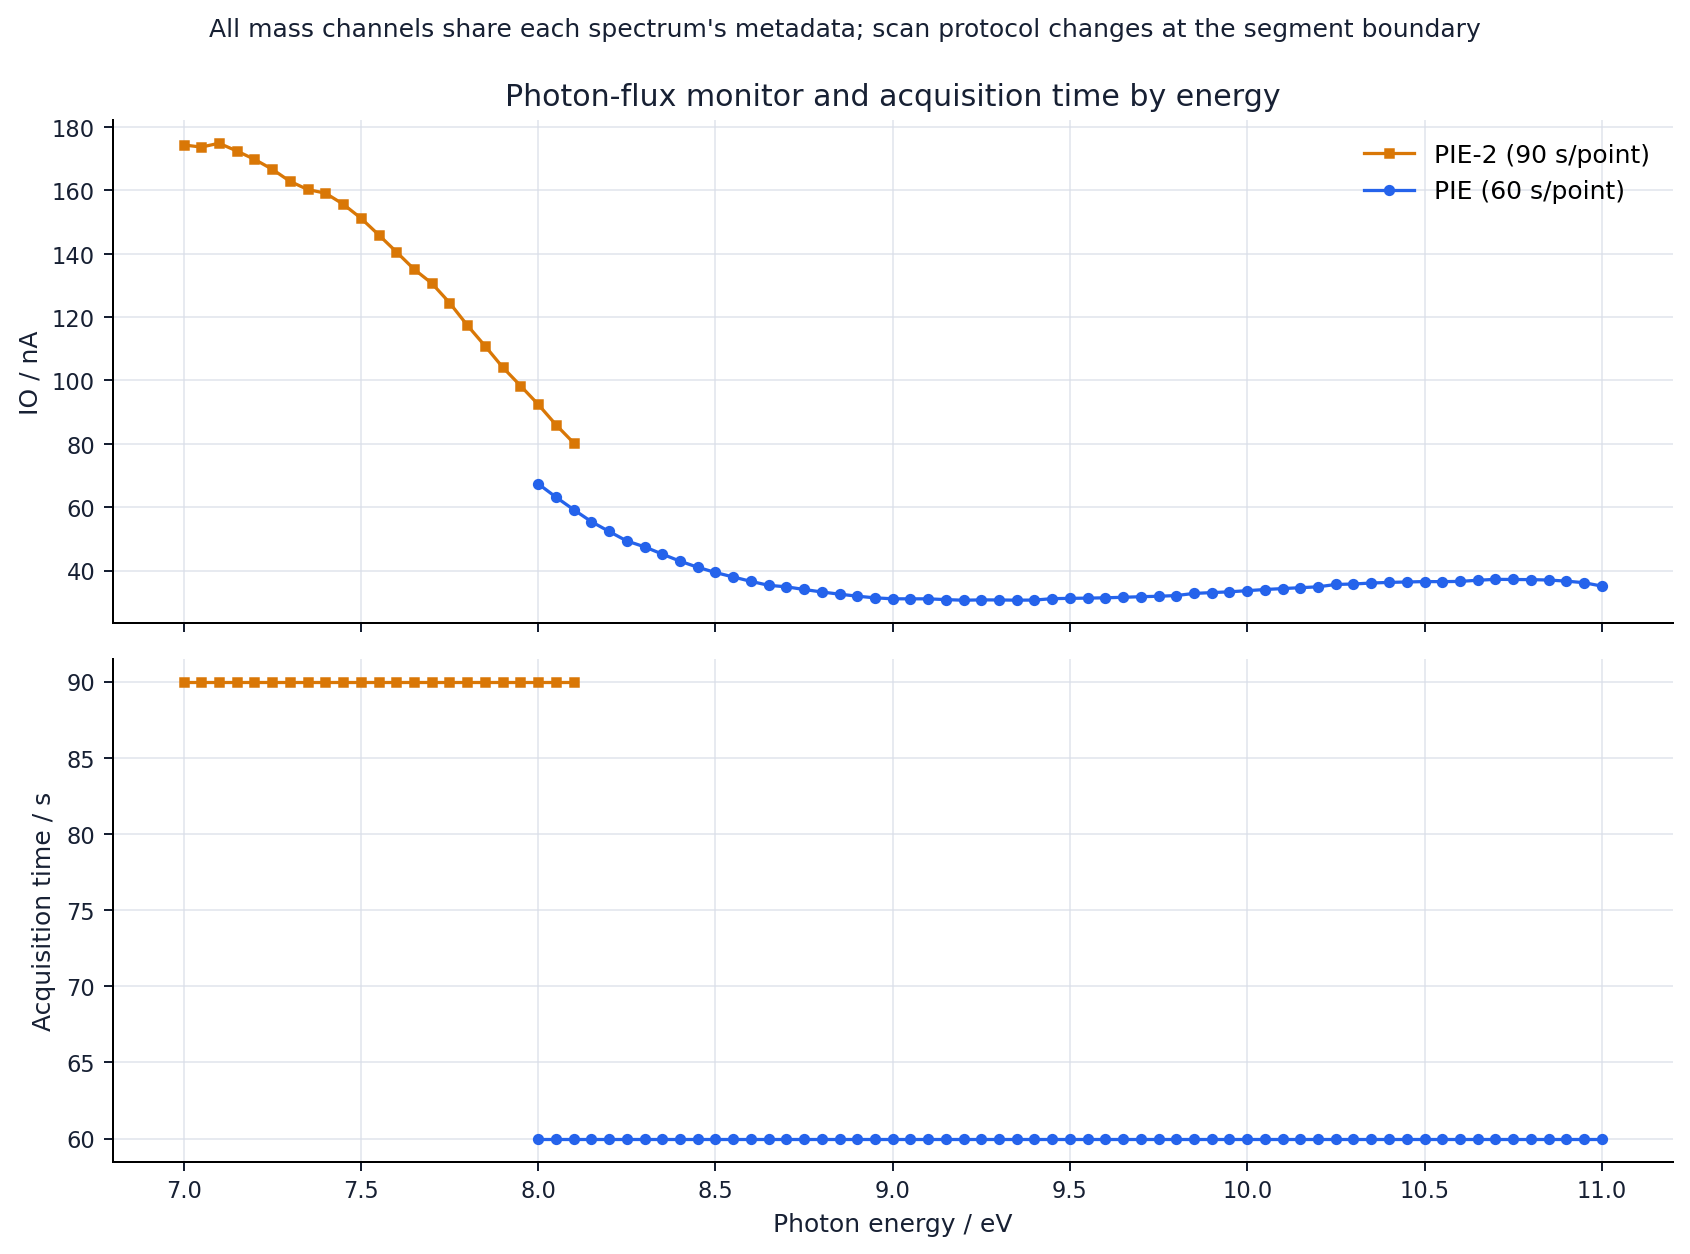

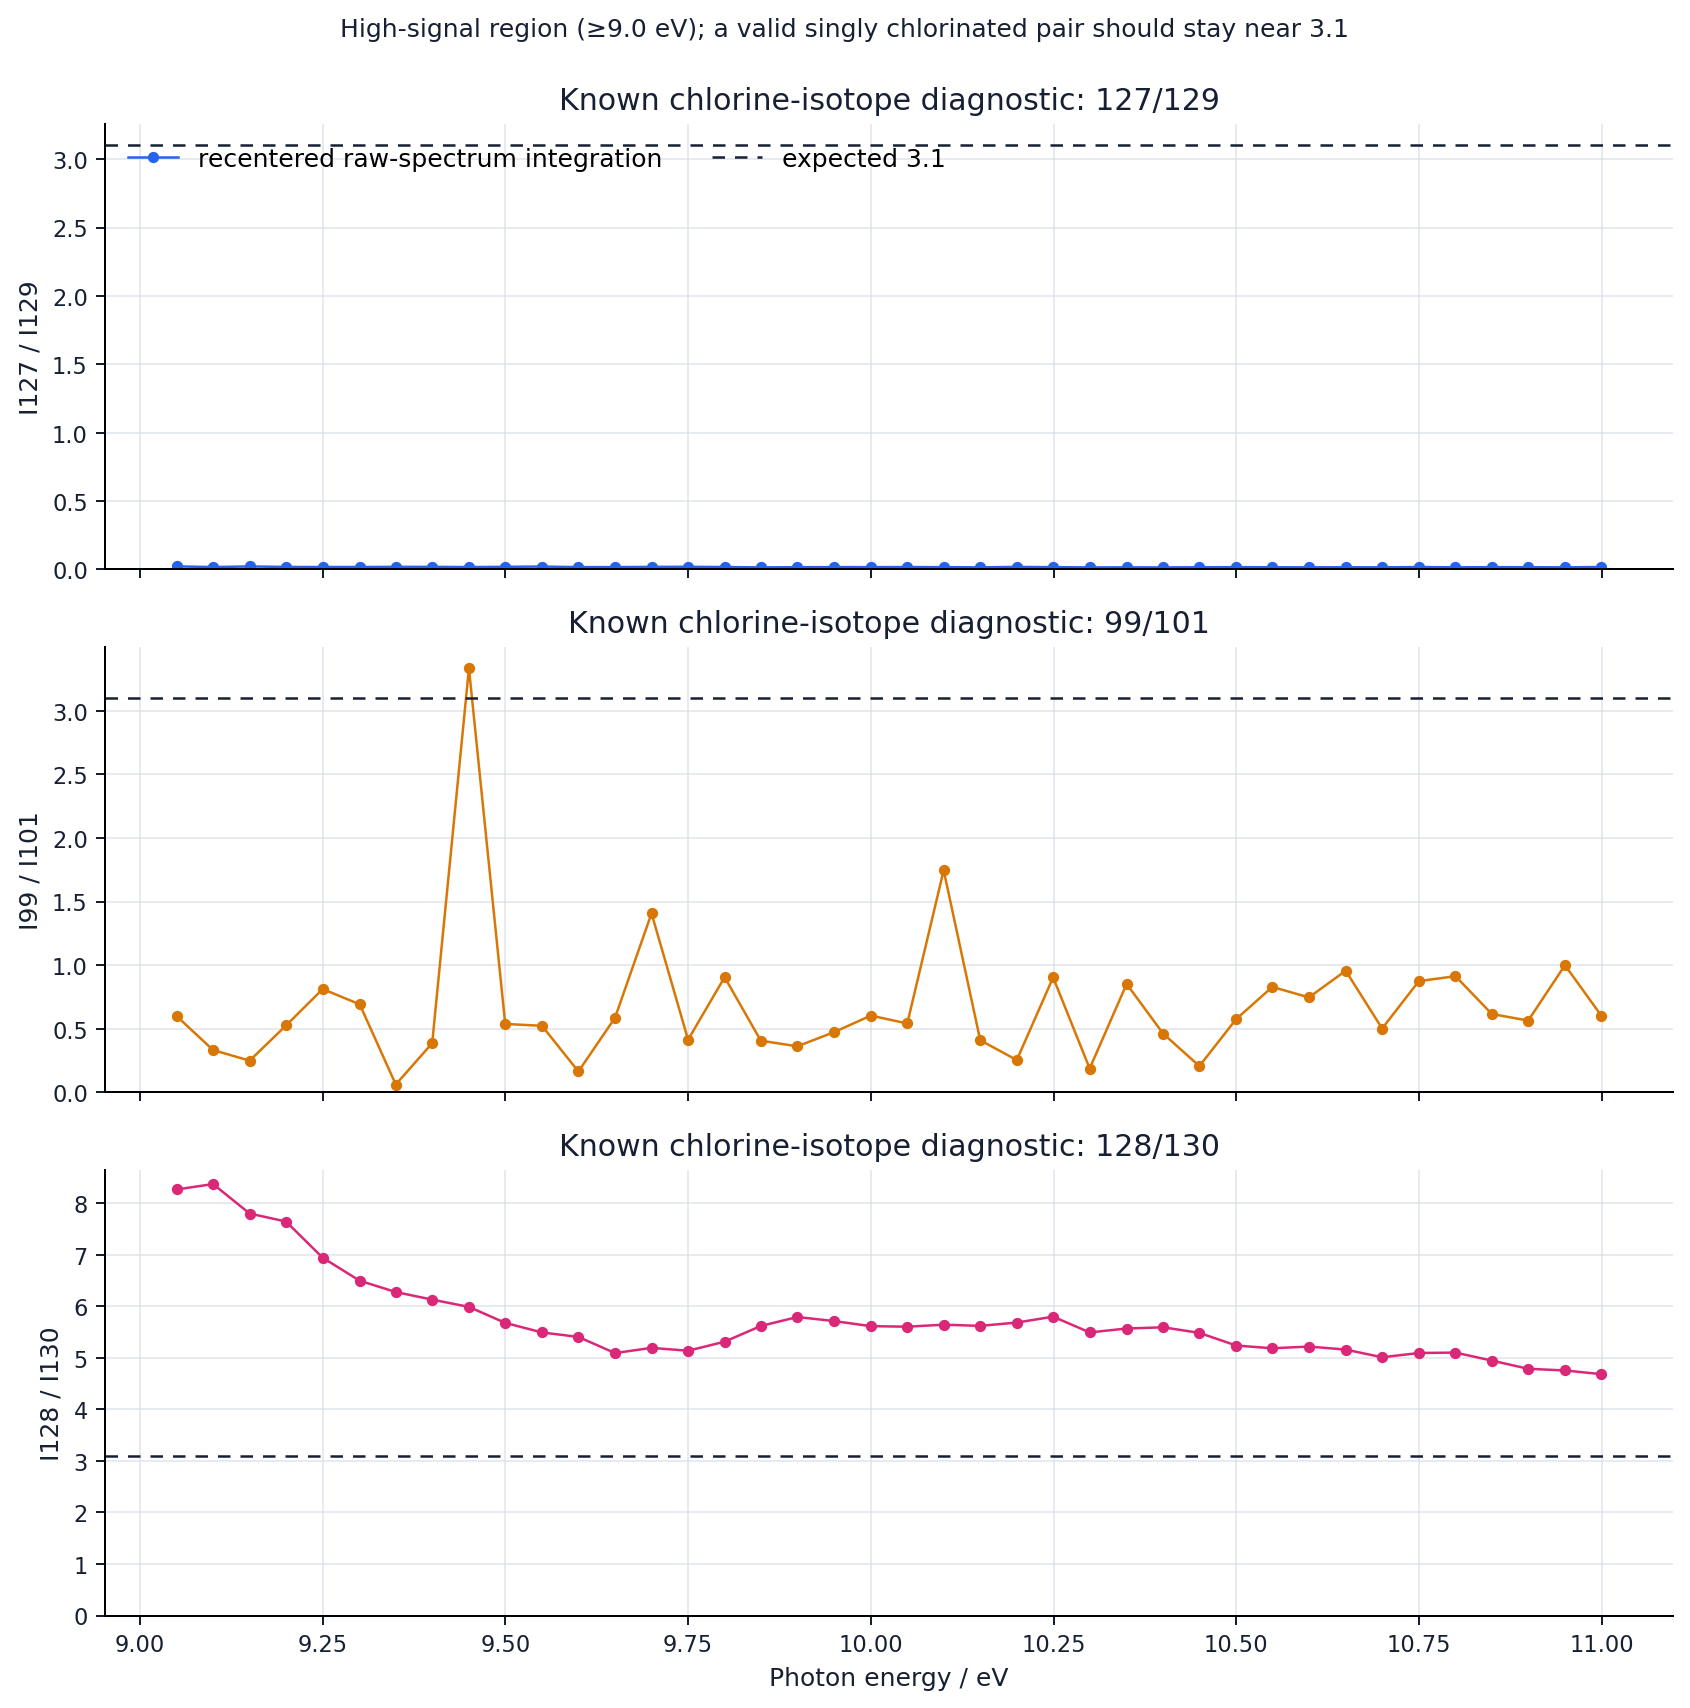

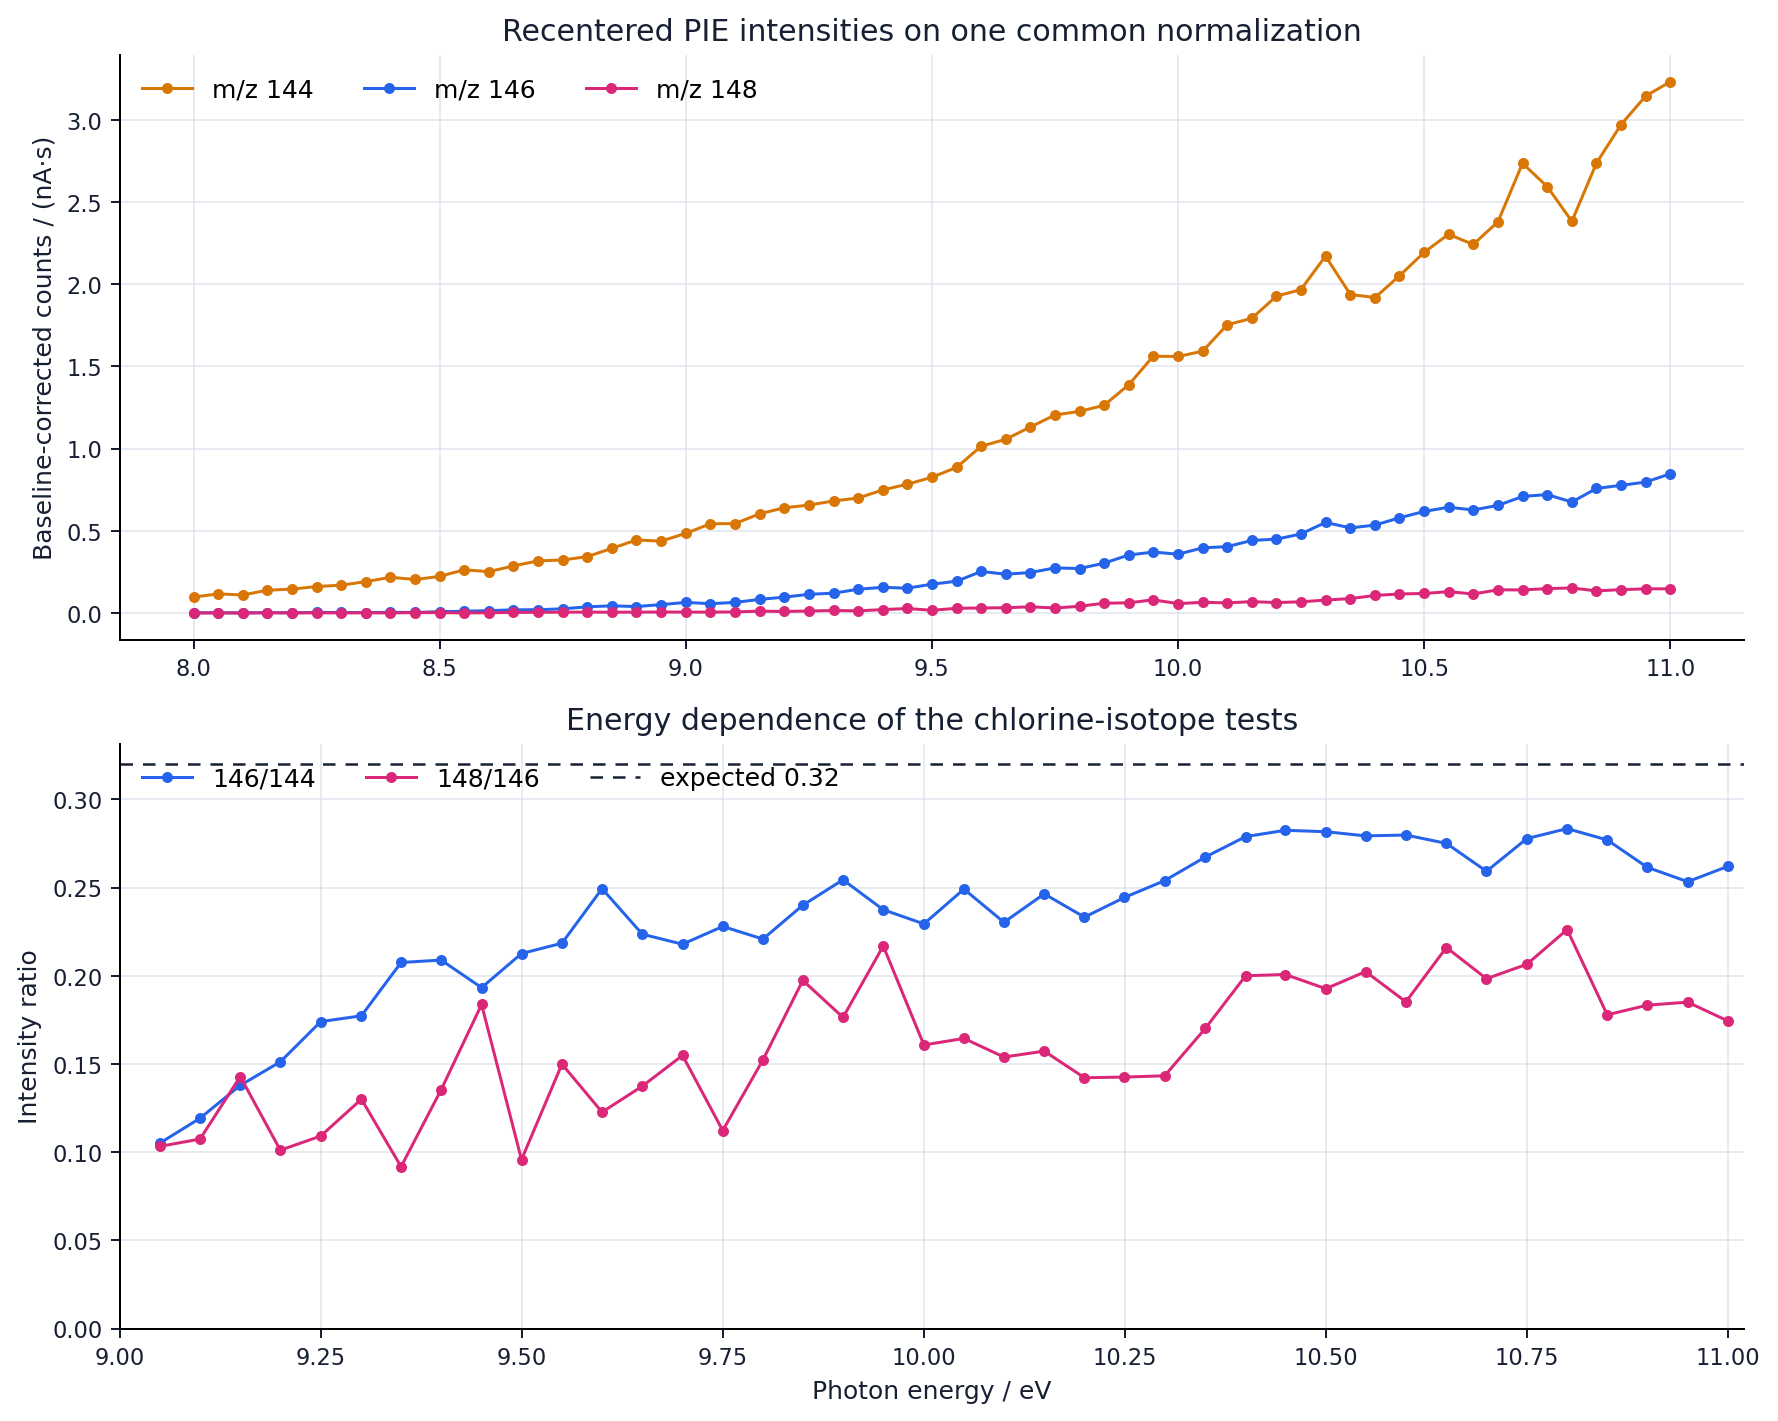

In [6]:
display(Image(filename='scan_conditions.png'))
display(Image(filename='known_isotope_ratios.png'))
display(Image(filename='target_relationships.png'))

## Takeaways

1. 在解释 142/144/146/148 的 PIE 形状之前，必须先用 PIE 数据自身重建或重定位峰窗；当前手动峰表不能继续直接使用。
2. 每个能量点的强度应至少除以 IO 和采集时间；两段扫描还需要用 8.00–8.10 eV 重叠区估计额外段间比例因子，且应按高信噪比通道分别验证。
3. 已知同位素对仍远离 3.1:1，说明窗口修复后仍有未分辨同量异位素/多物种叠加、邻峰尾部或质量依赖响应问题；在这些诊断通过前，不宜对 146 赋予新母体身份。
4. 148 与 146 的 PIE 总体相关，但最佳比例约 0.18 而非 0.32，且比值随能量增加；“共同上升”不足以证明同位素对应关系。